# Grid Search — High-Vol-Only Volatility Harvesting (Triplet)

This notebook performs a **grid search** over parameters for:

`backtest_vol_harvest_3asset_highvol_only(prices, tickers=(A,B,C), ...)`

It:
- Loads prices (CSV or yfinance)
- Runs the backtest for each parameter combination
- Computes a compact tearsheet (CAGR, Sharpe, MaxDD, Vol, Turnover, ActiveShare)
- Ranks configurations (optionally by OOS only)
- Visualizes results (tables + simple heatmaps)

No trend logic. Strategy is **only active during high volatility**.


## Setup

In [1]:
import itertools
from typing import Tuple, Optional, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)


## Load prices

In [2]:
# -----------------------------
# 1) Load prices for one triplet
# -----------------------------
# Option A: load from CSV
#  - CSV must have a date column + one column per ticker (prices)
#  - Example columns: Date, SPY, TLT, GLD
#
# Option B: fetch from yfinance (default)

USE_CSV = False
CSV_PATH = "prices_triplet.csv"  # if USE_CSV=True
DATE_COL = "Date"

TICKERS = ("JEPQ", "SGOV", "SGOL")
START = "2010-01-01"
END = None
AUTO_ADJUST = True

def load_prices_csv(path: str, date_col: str, tickers: Tuple[str,str,str]) -> pd.DataFrame:
    df = pd.read_csv(path)
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.set_index(date_col).sort_index()
    df.columns = [c.upper() for c in df.columns]
    cols = [t.upper() for t in tickers]
    return df[cols].dropna()

def fetch_prices_yf(tickers, start=START, end=END, auto_adjust=AUTO_ADJUST) -> pd.DataFrame:
    data = yf.download(
        list(tickers),
        start=start,
        end=end,
        auto_adjust=auto_adjust,
        progress=False,
        group_by="column",
        threads=True,
    )
    if isinstance(data.columns, pd.MultiIndex):
        px = data["Close"].copy()
    else:
        px = data[["Close"]].rename(columns={"Close": tickers[0]})
    px = px.dropna(how="all")
    px.columns = [c.upper() for c in px.columns]
    return px

if USE_CSV:
    px = load_prices_csv(CSV_PATH, DATE_COL, TICKERS)
else:
    px = fetch_prices_yf(TICKERS, start=START, end=END)

px = px.dropna()
print("px shape:", px.shape)
px.tail()


px shape: (943, 3)


,JEPQ,SGOL,SGOV
Date,,,
2026-01-30,58.964001,46.250000,100.360992
2026-02-02,59.380001,44.340000,100.370003
2026-02-03,58.619999,47.099998,100.389999
2026-02-04,57.680000,47.070000,100.400002
2026-02-05,56.930000,45.820000,100.400002


## Backtest function

In [3]:
# -----------------------------
# 2) High-vol-only backtest
# -----------------------------
def backtest_vol_harvest_3asset_highvol_only(
    prices: pd.DataFrame,
    *,
    tickers: tuple[str, str, str] = ("SPY", "TLT", "GLD"),
    start: str | None = None,
    end: str | None = None,
    rebalance: str = "W-FRI",             # "W-FRI" or "M"
    vol_lookback: int = 60,               # for risk-parity weights + vol targeting
    target_vol: float = 0.10,
    leverage_cap: float = 2.0,

    # High-vol gate
    high_vol_anchor: str = "SPY",
    high_vol_window: int = 63,
    high_vol_threshold: float = 0.20,     # annualized realized vol

    # NEW: drift-based rebalance trigger
    drift_threshold: float | None = 0.08, # L1 weight drift; None disables

    baseline_when_inactive: tuple[float, float, float] = (0.0, 1.0, 0.0),
    cost_bps: float = 1.0,
    periods_per_year: int = 252,
) -> dict:
    """
    High-vol-only volatility harvesting with drift-based rebalancing.
    """
    cols = list(tickers)

    # -----------------------------
    # Prices / returns
    # -----------------------------
    px = prices.copy()
    px.index = pd.to_datetime(px.index).tz_localize(None)
    if start:
        px = px.loc[px.index >= pd.to_datetime(start)]
    if end:
        px = px.loc[px.index <= pd.to_datetime(end)]
    px = px[cols].dropna()

    r = px.pct_change().dropna()
    idx = r.index
    if len(px) < max(vol_lookback, high_vol_window) + 10:
        raise ValueError("Not enough history for requested windows.")

    # -----------------------------
    # High-vol activation signal
    # -----------------------------
    rv = (
        r[high_vol_anchor]
        .rolling(high_vol_window)
        .std(ddof=1) * np.sqrt(periods_per_year)
    )
    active = (rv >= high_vol_threshold).astype(float).reindex(idx).fillna(0.0)

    # -----------------------------
    # Risk-parity weights (shifted)
    # -----------------------------
    vol = r.rolling(vol_lookback).std(ddof=1).shift(1)
    inv = 1.0 / vol.replace(0.0, np.nan)
    w_rp = inv.div(inv.sum(axis=1), axis=0)
    w_rp = w_rp.reindex(idx).fillna(pd.Series([1/3, 1/3, 1/3], index=cols)).ffill()

    # -----------------------------
    # Baseline weights (inactive)
    # -----------------------------
    w_base = pd.DataFrame(
        np.tile(np.array(baseline_when_inactive, dtype=float), (len(idx), 1)),
        index=idx,
        columns=cols,
    )
    w_base = w_base.div(w_base.sum(axis=1), axis=0)

    # -----------------------------
    # Target weights
    # -----------------------------
    cond = (active.values > 0.5).reshape(-1, 1)
    w_target = pd.DataFrame(
        np.where(cond, w_rp.values, w_base.values),
        index=idx,
        columns=cols,
    )

    # -----------------------------
    # Rebalance dates
    # -----------------------------
    rb_dates = px.resample(rebalance).last().index.intersection(idx)
    if len(rb_dates) < 2:
        raise ValueError("Not enough rebalance points.")
    rb_set = set(rb_dates)

    # -----------------------------
    # Constant-mix engine (calendar + drift)
    # -----------------------------
    w_applied = pd.DataFrame(index=idx, columns=cols, dtype=float)
    turnover = pd.Series(0.0, index=idx)
    gross_port = pd.Series(0.0, index=idx)

    vals = pd.Series(w_target.iloc[0].values, index=cols, dtype=float)
    pv = 1.0

    for i, dt in enumerate(idx):
        if i == 0:
            w_applied.loc[dt] = vals.values
            continue

        # evolve sleeves
        vals = vals * (1.0 + r.loc[dt, cols])
        pv_now = float(vals.sum())

        w_now = (vals / pv_now).values
        w_tgt = w_target.loc[dt, cols].values

        # drift (L1 distance)
        drift = float(np.abs(w_now - w_tgt).sum())

        # rebalance condition
        need_reb = (
            (dt in rb_set and active.loc[dt] > 0.5)
            or (drift_threshold is not None and drift >= drift_threshold)
        )

        if need_reb:
            to = drift
            cost = (cost_bps / 1e4) * to * pv_now
            pv_after = max(pv_now - cost, 0.0)
            vals = pd.Series(pv_after * w_tgt, index=cols)
            pv_new = pv_after
            turnover.loc[dt] = to
        else:
            pv_new = pv_now

        gross_port.loc[dt] = (pv_new / pv) - 1.0
        pv = pv_new
        w_applied.loc[dt] = (vals / pv).values if pv > 0 else w_tgt

    # -----------------------------
    # Portfolio vol targeting
    # -----------------------------
    realized = gross_port.rolling(vol_lookback).std(ddof=1) * np.sqrt(periods_per_year)
    lev = (target_vol / realized).clip(0.0, leverage_cap).shift(1).fillna(1.0)

    net = (gross_port * lev).rename("returns").dropna()
    equity = (1.0 + net).cumprod().rename("equity")

    return {
        "returns": net,
        "equity": equity,
        "weights": w_applied.reindex(net.index),
        "turnover": turnover.reindex(net.index),
        "leverage": lev.reindex(net.index),
        "signals": {
            "active": active.reindex(net.index),
            "realized_vol": rv.reindex(net.index),
        },
        "Params": {
            "tickers": tickers,
            "rebalance": rebalance,
            "drift_threshold": drift_threshold,
            "vol_lookback": vol_lookback,
            "target_vol": target_vol,
            "high_vol_window": high_vol_window,
            "high_vol_threshold": high_vol_threshold,
            "baseline_when_inactive": baseline_when_inactive,
            "cost_bps": cost_bps,
        },
    }


## Metrics

In [4]:
# -----------------------------
# 3) Tearsheet + helpers
# -----------------------------
def tearsheet_stats(
    returns: pd.Series,
    *,
    turnover: pd.Series | None = None,
    active: pd.Series | None = None,
    periods_per_year: int = 252,
) -> dict:
    r = returns.dropna()
    eq = (1.0 + r).cumprod()
    dd = eq / eq.cummax() - 1.0

    ann_ret = r.mean() * periods_per_year
    ann_vol = r.std(ddof=1) * np.sqrt(periods_per_year)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else np.nan

    years = len(eq) / periods_per_year
    cagr = eq.iloc[-1] ** (1.0 / years) - 1.0 if years > 0 else np.nan

    out = {
        "CAGR": float(cagr),
        "Sharpe": float(sharpe),
        "AnnualVol": float(ann_vol),
        "MaxDD": float(dd.min()),
    }
    if turnover is not None:
        out["AvgDailyTurnover"] = float(turnover.mean())
    if active is not None:
        out["ActiveShare"] = float(active.mean())
    return out

def oos_split(returns: pd.Series, oos_frac: float = 0.30):
    r = returns.dropna()
    n = len(r)
    split = max(1, int(np.floor(n * (1 - oos_frac))))
    return r.iloc[:split], r.iloc[split:]

def score_row(stats: dict, *, use_oos: bool = False) -> float:
    # Generic scoring: reward Sharpe/CAGR, penalize MaxDD/turnover
    s = stats.get("Sharpe", np.nan)
    c = stats.get("CAGR", np.nan)
    mdd = abs(stats.get("MaxDD", np.nan))
    to = stats.get("AvgDailyTurnover", 0.0)

    if not np.isfinite(s) or not np.isfinite(c) or not np.isfinite(mdd):
        return -np.inf
    return (1.0 * s) + (2.0 * c) - (1.0 * mdd) - (0.5 * to)


## Grid

In [6]:
# -----------------------------
# 4) Grid search configuration
# -----------------------------
# Choose a *small* grid first, then expand.
GRID = {
    "rebalance": ["W-FRI", "M"],
    "vol_lookback": [40, 60, 90],
    "target_vol": [0.08, 0.10, 0.12],
    "leverage_cap": [1.5, 2.0],
    "high_vol_window": [42, 63, 84],
    "high_vol_threshold": [0.18, 0.20, 0.22],
    # costs (optional)
    "cost_bps": [1.0],
}

# Fixed knobs for this triplet
FIXED = dict(
    tickers=TICKERS,
    start=START,
    end=END,
    high_vol_anchor="SGOL",                 # anchor must be in triplet
    baseline_when_inactive=(0.0, 1.0, 0.0),     # park in 2nd ticker when inactive
    periods_per_year=252,
)

OOS_FRAC = 0.30
RANK_ON = "OOS"   # "OOS" or "ALL"


## Run grid search

In [7]:
# -----------------------------
# 5) Run grid search
# -----------------------------
keys = list(GRID.keys())
values = [GRID[k] for k in keys]

rows = []
fail = 0

for combo in itertools.product(*values):
    params = dict(zip(keys, combo))
    try:
        bt = backtest_vol_harvest_3asset_highvol_only(
            px, **FIXED, **params
        )

        r_all = bt["returns"]
        r_is, r_oos = oos_split(r_all, oos_frac=OOS_FRAC)

        st_all = tearsheet_stats(r_all, turnover=bt["turnover"], active=bt["signals"]["active"])
        st_is  = tearsheet_stats(r_is)
        st_oos = tearsheet_stats(r_oos)

        row = {**params}
        # keep key stats
        row.update({
            "ALL_Sharpe": st_all["Sharpe"],
            "ALL_CAGR": st_all["CAGR"],
            "ALL_MaxDD": st_all["MaxDD"],
            "ALL_AnnVol": st_all["AnnualVol"],
            "ALL_Turnover": st_all.get("AvgDailyTurnover", np.nan),
            "ALL_Active": st_all.get("ActiveShare", np.nan),

            "OOS_Sharpe": st_oos["Sharpe"],
            "OOS_CAGR": st_oos["CAGR"],
            "OOS_MaxDD": st_oos["MaxDD"],
            "OOS_AnnVol": st_oos["AnnualVol"],
        })

        row["Score"] = score_row({
            "Sharpe": row["OOS_Sharpe"] if RANK_ON=="OOS" else row["ALL_Sharpe"],
            "CAGR":   row["OOS_CAGR"]   if RANK_ON=="OOS" else row["ALL_CAGR"],
            "MaxDD":  row["OOS_MaxDD"]  if RANK_ON=="OOS" else row["ALL_MaxDD"],
            "AvgDailyTurnover": row.get("ALL_Turnover", 0.0),
        })

        rows.append(row)
    except Exception:
        fail += 1

results = pd.DataFrame(rows).sort_values("Score", ascending=False)
print("Ran:", len(results), "failures:", fail)
results.head(20)


Ran: 324 failures: 0


,rebalance,vol_lookback,target_vol,leverage_cap,high_vol_window,high_vol_threshold,cost_bps,ALL_Sharpe,ALL_CAGR,ALL_MaxDD,ALL_AnnVol,ALL_Turnover,ALL_Active,OOS_Sharpe,OOS_CAGR,OOS_MaxDD,OOS_AnnVol,Score
14,W-FRI,40,0.08,2.0,63,0.22,1.0,17.348534,0.091123,-0.001238,0.005028,0.000360,0.111465,18.331409,0.091186,-0.001238,0.004762,18.512364
32,W-FRI,40,0.10,2.0,63,0.22,1.0,17.348534,0.091123,-0.001238,0.005028,0.000360,0.111465,18.331409,0.091186,-0.001238,0.004762,18.512364
50,W-FRI,40,0.12,2.0,63,0.22,1.0,17.348534,0.091123,-0.001238,0.005028,0.000360,0.111465,18.331409,0.091186,-0.001238,0.004762,18.512364
41,W-FRI,40,0.12,1.5,63,0.22,1.0,17.364090,0.067676,-0.000929,0.003772,0.000360,0.111465,18.331409,0.067644,-0.000929,0.003571,18.465588
5,W-FRI,40,0.08,1.5,63,0.22,1.0,17.364090,0.067676,-0.000929,0.003772,0.000360,0.111465,18.331409,0.067644,-0.000929,0.003571,18.465588
23,W-FRI,40,0.10,1.5,63,0.22,1.0,17.364090,0.067676,-0.000929,0.003772,0.000360,0.111465,18.331409,0.067644,-0.000929,0.003571,18.465588
104,W-FRI,60,0.12,2.0,63,0.22,1.0,17.295483,0.090504,-0.000983,0.005011,0.000288,0.111465,18.080150,0.090157,-0.000983,0.004776,18.259337
86,W-FRI,60,0.10,2.0,63,0.22,1.0,17.295483,0.090504,-0.000983,0.005011,0.000288,0.111465,18.080150,0.090157,-0.000983,0.004776,18.259337
68,W-FRI,60,0.08,2.0,63,0.22,1.0,17.295483,0.090504,-0.000983,0.005011,0.000288,0.111465,18.080150,0.090157,-0.000983,0.004776,18.259337
77,W-FRI,60,0.10,1.5,63,0.22,1.0,17.315592,0.067297,-0.000737,0.003762,0.000288,0.111465,18.080150,0.066888,-0.000737,0.003582,18.213045


## Best configuration

In [8]:
# -----------------------------
# 6) Visualize top config
# -----------------------------
best = results.iloc[0].to_dict()
best


{'rebalance': 'W-FRI',
 'vol_lookback': 40,
 'target_vol': 0.08,
 'leverage_cap': 2.0,
 'high_vol_window': 63,
 'high_vol_threshold': 0.22,
 'cost_bps': 1.0,
 'ALL_Sharpe': 17.348534294317947,
 'ALL_CAGR': 0.09112259555684998,
 'ALL_MaxDD': -0.0012380876404350927,
 'ALL_AnnVol': 0.005028366274806917,
 'ALL_Turnover': 0.0003595480024470833,
 'ALL_Active': 0.11146496815286625,
 'OOS_Sharpe': 18.331409106425465,
 'OOS_CAGR': 0.0911864677143428,
 'OOS_MaxDD': -0.0012380876404350927,
 'OOS_AnnVol': 0.004761882271581198,
 'Score': 18.51236418021249}

In [9]:
# Re-run best configuration for plots
best_params = {k: best[k] for k in GRID.keys()}

bt_best = backtest_vol_harvest_3asset_highvol_only(px, **FIXED, **best_params)

st_best = tearsheet_stats(bt_best["returns"], turnover=bt_best["turnover"], active=bt_best["signals"]["active"])
pd.Series({
    "CAGR": f"{st_best['CAGR']:.2%}",
    "Sharpe": f"{st_best['Sharpe']:.2f}",
    "AnnualVol": f"{st_best['AnnualVol']:.2%}",
    "MaxDD": f"{st_best['MaxDD']:.2%}",
    "AvgDailyTurnover": f"{st_best.get('AvgDailyTurnover', np.nan):.3f}",
    "ActiveShare": f"{st_best.get('ActiveShare', np.nan):.1%}",
})


CAGR                 9.11%
Sharpe               17.35
AnnualVol            0.50%
MaxDD               -0.12%
AvgDailyTurnover     0.000
ActiveShare          11.1%
dtype: object

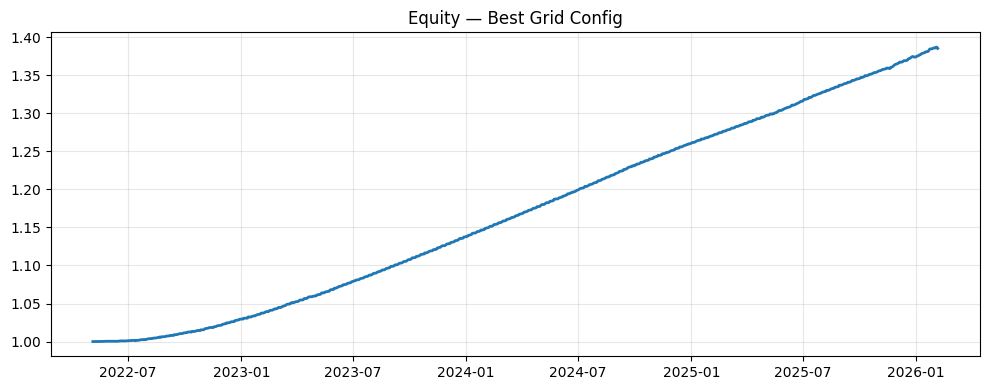

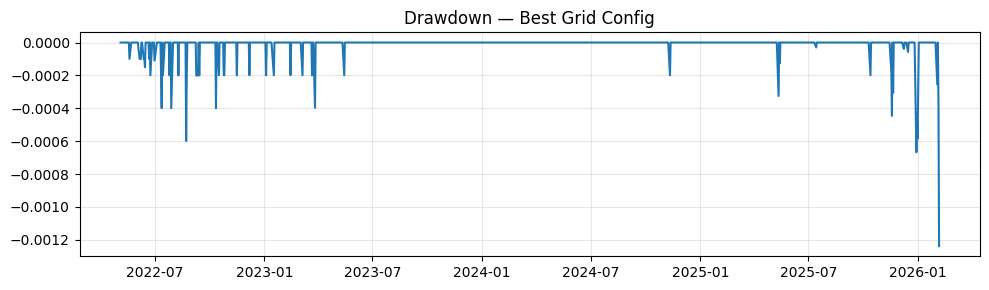

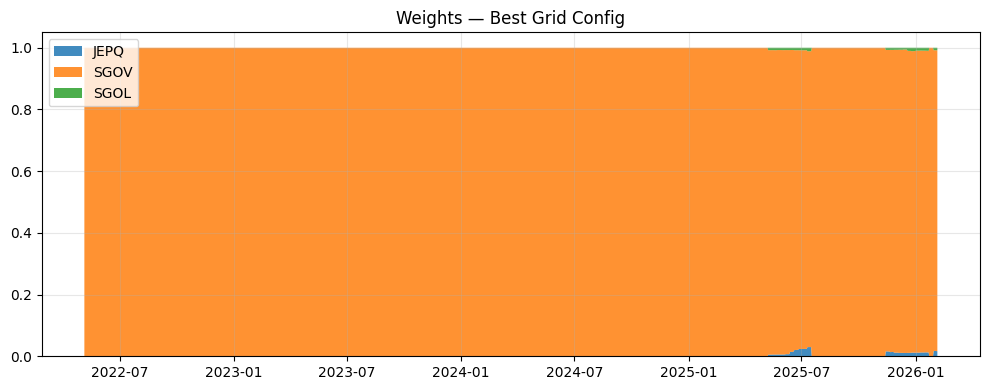

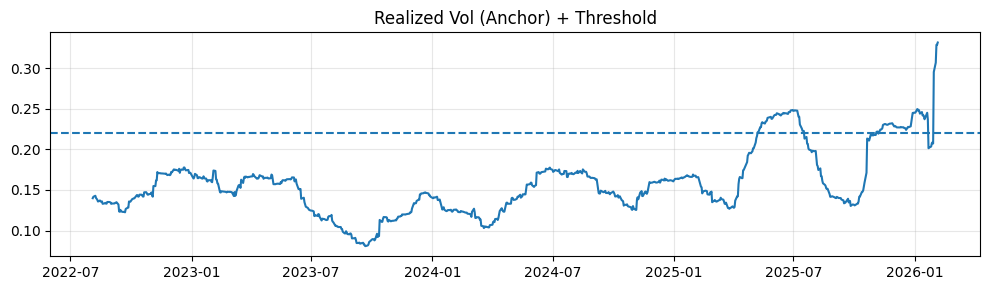

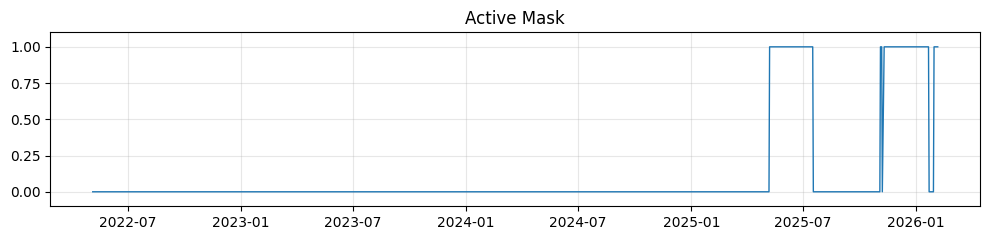

In [10]:
eq = bt_best["equity"]
dd = eq / eq.cummax() - 1.0
w  = bt_best["weights"]
rv = bt_best["signals"]["realized_vol"]
am = bt_best["signals"]["active"]

plt.figure(figsize=(10,4))
plt.plot(eq.index, eq.values, linewidth=2)
plt.title("Equity — Best Grid Config")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,3))
plt.plot(dd.index, dd.values, linewidth=1.5)
plt.title("Drawdown — Best Grid Config")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))
plt.stackplot(w.index, w.T.values, labels=w.columns, alpha=0.85)
plt.title("Weights — Best Grid Config")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,3))
plt.plot(rv.index, rv.values, linewidth=1.5)
plt.axhline(best_params["high_vol_threshold"], linestyle="--")
plt.title("Realized Vol (Anchor) + Threshold")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,2.5))
plt.plot(am.index, am.values, linewidth=1.0)
plt.title("Active Mask")
plt.ylim(-0.1, 1.1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Heatmap

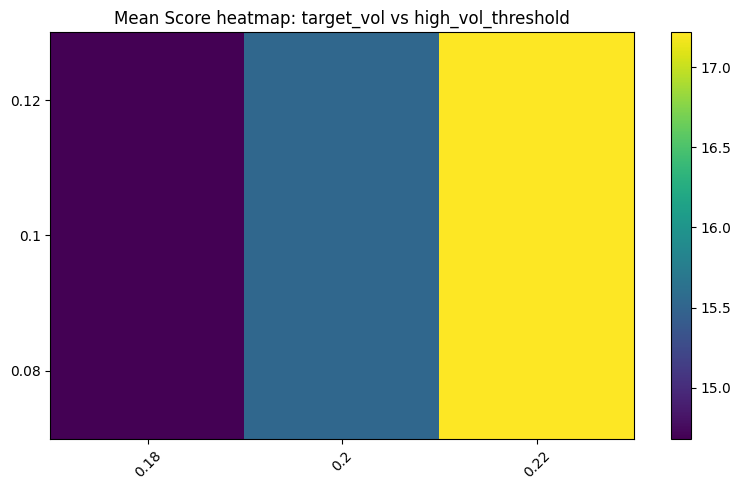

high_vol_threshold,0.18,0.20,0.22
target_vol,,,
0.08,14.682589,15.526205,17.216488
0.10,14.682589,15.526205,17.216488
0.12,14.682589,15.526205,17.216488


In [11]:
# -----------------------------
# 7) Simple heatmap example
# -----------------------------
# Pick 2 parameters to visualize (pivoted heatmap of Score)
X = "high_vol_threshold"
Y = "target_vol"

pivot = results.pivot_table(index=Y, columns=X, values="Score", aggfunc="mean")
pivot = pivot.sort_index().sort_index(axis=1)

plt.figure(figsize=(8,5))
plt.imshow(pivot.values, aspect="auto", origin="lower")
plt.xticks(range(len(pivot.columns)), [str(x) for x in pivot.columns], rotation=45)
plt.yticks(range(len(pivot.index)), [str(y) for y in pivot.index])
plt.title(f"Mean Score heatmap: {Y} vs {X}")
plt.colorbar()
plt.tight_layout()
plt.show()

pivot


## Export

In [12]:
# -----------------------------
# 8) Export grid results
# -----------------------------
OUT_CSV = "gridsearch_results.csv"
results.to_csv(OUT_CSV, index=False)
print("Wrote:", OUT_CSV)


Wrote: gridsearch_results.csv
